## Property 2c: Central Members (between categories)

In [ ]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np
from collections import defaultdict
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr

In [7]:
# Import Data

attributes_df  = pd.read_csv('01_catmemexp_attributestask_allmodels_processed_3.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df['output_list_processed_nonoise'] = attributes_df['output_list_processed_nonoise'].apply(ast.literal_eval)

items_df = pd.read_csv('01_catmemexp_itemstask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

unique_attributes_df  = pd.read_csv('famres_scores_df.csv')
unique_attributes_df.head()

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency
0,Qwen2.5-7B-Instruct,Furniture,armchair,"['portable', 'reclining', 'wooden', 'comfortab...","[np.int64(3), np.int64(2), np.int64(13), np.in...",44,12.727720,22
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"['shelves', 'spacious', 'wooden', 'tall', 'fur...","[np.int64(1), np.int64(4), np.int64(13), np.in...",52,12.727720,29
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"['wooden', 'multi-level', 'compact', 'bed', 's...","[np.int64(13), np.int64(3), np.int64(3), np.in...",28,5.455321,9
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"['wooden', 'furniture', 'cabinetry', 'shelved'...","[np.int64(13), np.int64(5), np.int64(2), np.in...",46,11.341425,8
4,Qwen2.5-7B-Instruct,Furniture,chair,"['portable', 'wooden', 'functional', 'four-leg...","[np.int64(3), np.int64(13), np.int64(7), np.in...",54,15.079095,30


In [ ]:
unique_attributes_df["frequency"] = pd.to_numeric(unique_attributes_df["frequency"], errors="coerce")

df_clean = unique_attributes_df.dropna(subset=["frequency"])

tables = {}

for (model, category), group in df_clean.groupby(["model", "category"]):
    table = (
        group[["item", "frequency"]]
        .sort_values(by="frequency", ascending=False)
        .reset_index(drop=True)
    )
    
    tables[(model, category)] = table

for (model, category), table in tables.items():
    print(f"\nModel: {model} | Category: {category}")
    print(table)


Model: Meta-Llama-3.1-70B-Instruct | Category: Clothing
         item  frequency
0        boot         30
1      jacket         30
2        jean         30
3       shirt         30
4        shoe         30
5     sweater         30
6     t-shirt         29
7   underwear         29
8      hoodie         25
9      sandal         25
10       vest         20
11     pajama         11
12      tight          6
13    earmuff          5
14   leggings          5
15   swimsuit          5

Model: Meta-Llama-3.1-70B-Instruct | Category: Fruit
              item  frequency
0            apple         30
1           banana         30
2           cherry         30
3            lemon         30
4       strawberry         30
5             kiwi         30
6              fig         27
7           papaya         27
8            guava         27
9       grapefruit         19
10            date         15
11    passionfruit         11
12      acai berry         11
13      blackberry         10
14  honeydew m

In [ ]:
item_occurrences_all = {}

for model in items_df['model'].unique():
    model_df = items_df[items_df['model'] == model]
    categories = model_df['category'].unique()
    
    for category in categories:
       
        items = model_df[model_df['category'] == category]['output_list_processed_nonoise'].sum()
        
        for item in set(items):
            
            if item not in item_occurrences_all:
                item_occurrences_all[item] = {
                    'model': model,
                    'categories': {},
                    'total_count': 0
                }
            
            count_in_category = model_df[model_df['output_list_processed_nonoise'].apply(lambda x: item in x) & 
                                          (model_df['category'] == category)].shape[0]
            item_occurrences_all[item]['categories'][category] = count_in_category
            item_occurrences_all[item]['total_count'] += count_in_category

results_list = []
for item, info in item_occurrences_all.items():
    if len(info['categories']) > 2: 
        for category, count in info['categories'].items():
            results_list.append({
                'Item': item,
                'Model': info['model'],
                'Category': category,
                'Category Frequency': count,
                'Total Count': info['total_count'],
            })

results_df = pd.DataFrame(results_list)

results_df

,Item,Model,Category,Category Frequency,Total Count
0,ostrich,Qwen2.5-7B-Instruct,Bird,30,175
1,ostrich,Qwen2.5-7B-Instruct,Vehicle,3,175
2,ostrich,Qwen2.5-7B-Instruct,Clothing,2,175
3,kiwi,Qwen2.5-7B-Instruct,Bird,30,403
4,kiwi,Qwen2.5-7B-Instruct,Fruit,30,403
...,...,...,...,...,...
714,hook,deepseek-chat,Furniture,5,13
715,hook,deepseek-chat,Weapon,2,13
716,metal,deepseek-chat,Clothing,3,7
717,metal,deepseek-chat,Furniture,2,7


In [ ]:
# Function to assign category dominance values
def assign_category_dominance(group):
    group = group.sort_values(by='Category Frequency', ascending=False)
    group['category_dominance_deco'] = 1  
    if len(group) == 1:
        group['category_dominance_deco'] = 3  
        return group
    if len(group) >= 2:
        group.iloc[0, group.columns.get_loc('category_dominance_deco')] = 3  
        group.iloc[1, group.columns.get_loc('category_dominance_deco')] = 2  
        if len(group) > 2:
            group.iloc[2:, group.columns.get_loc('category_dominance_deco')] = 1  
    return group

results_df = results_df.groupby(['Model', 'Item']).apply(assign_category_dominance)

results_df.reset_index(drop=True, inplace=True)

results_df = results_df.drop(columns=['Total Count'])

results_df

C:\Users\AS\AppData\Local\Temp\ipykernel_13524\3881451629.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df = results_df.groupby(['Model', 'Item']).apply(assign_category_dominance)


,Item,Model,Category,Category Frequency,category_dominance_deco
0,battleship,Meta-Llama-3.1-70B-Instruct,Weapon,11,3
1,battleship,Meta-Llama-3.1-70B-Instruct,Vehicle,6,2
2,battleship,Meta-Llama-3.1-70B-Instruct,Toy,4,1
3,pool,Meta-Llama-3.1-70B-Instruct,Sport,21,3
4,pool,Meta-Llama-3.1-70B-Instruct,Toy,3,2
...,...,...,...,...,...
714,wood,gemini-3-pro,Clothing,3,2
715,wood,gemini-3-pro,Furniture,2,1
716,yarn,gemini-3-pro,Clothing,5,3
717,yarn,gemini-3-pro,Toy,3,2


In [ ]:
correlation_results = []

grouped = results_df.groupby(['Model', 'Category'])

for (model, category), group in grouped:
    
    correlation, _ = spearmanr(group['category_dominance_deco'], group['Category Frequency'])
    correlation_results.append({'Model': model, 'Category': category, 'Correlation': correlation})

correlation_df = pd.DataFrame(correlation_results)

plt.figure(figsize=(12, 6))
sns.barplot(data=correlation_df, x='Category', y='Correlation', hue='Model')
plt.title('Spearman Correlation between Category Dominance and Category Frequency')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Spearman Correlation Coefficient')
plt.xlabel('Category')
plt.legend(title='Model', loc='lower left', bbox_to_anchor=(0, 0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\AS\AppData\Local\Temp\ipykernel_13524\2285309822.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(group['category_dominance_deco'], group['Category Frequency'])


Spearman correlations for all model-category pairs:
Category: Clothing, Model: DeepSeek, p-value: 0.0000 ***
Category: Clothing, Model: Gemini 3 Pro, p-value: 0.0000 ***
Category: Clothing, Model: Meta-Llama-3.1-8B-Instruct, p-value: 0.0399 *
Category: Clothing, Model: Qwen2.5-14B-Instruct, p-value: 0.0010 ***
Category: Clothing, Model: Qwen2.5-32B-Instruct, p-value: 0.2431 
Category: Clothing, Model: Qwen2.5-72B-Instruct, p-value: 0.3333 
Category: Clothing, Model: Qwen2.5-7B-Instruct, p-value: 0.0002 ***
Category: Fruit, Model: Humans, p-value: 0.0000 ***
Category: Fruit, Model: Qwen2.5-14B-Instruct, p-value: 0.0000 ***
Category: Fruit, Model: Qwen2.5-7B-Instruct, p-value: 0.8425 
Category: Furniture, Model: Humans, p-value: 0.0000 ***
Category: Furniture, Model: DeepSeek, p-value: 0.0262 *
Category: Furniture, Model: Gemini 3 Pro, p-value: 0.0000 ***
Category: Furniture, Model: Meta-Llama-3.1-8B-Instruct, p-value: 0.0003 ***
Category: Furniture, Model: Qwen2.5-14B-Instruct, p-value:

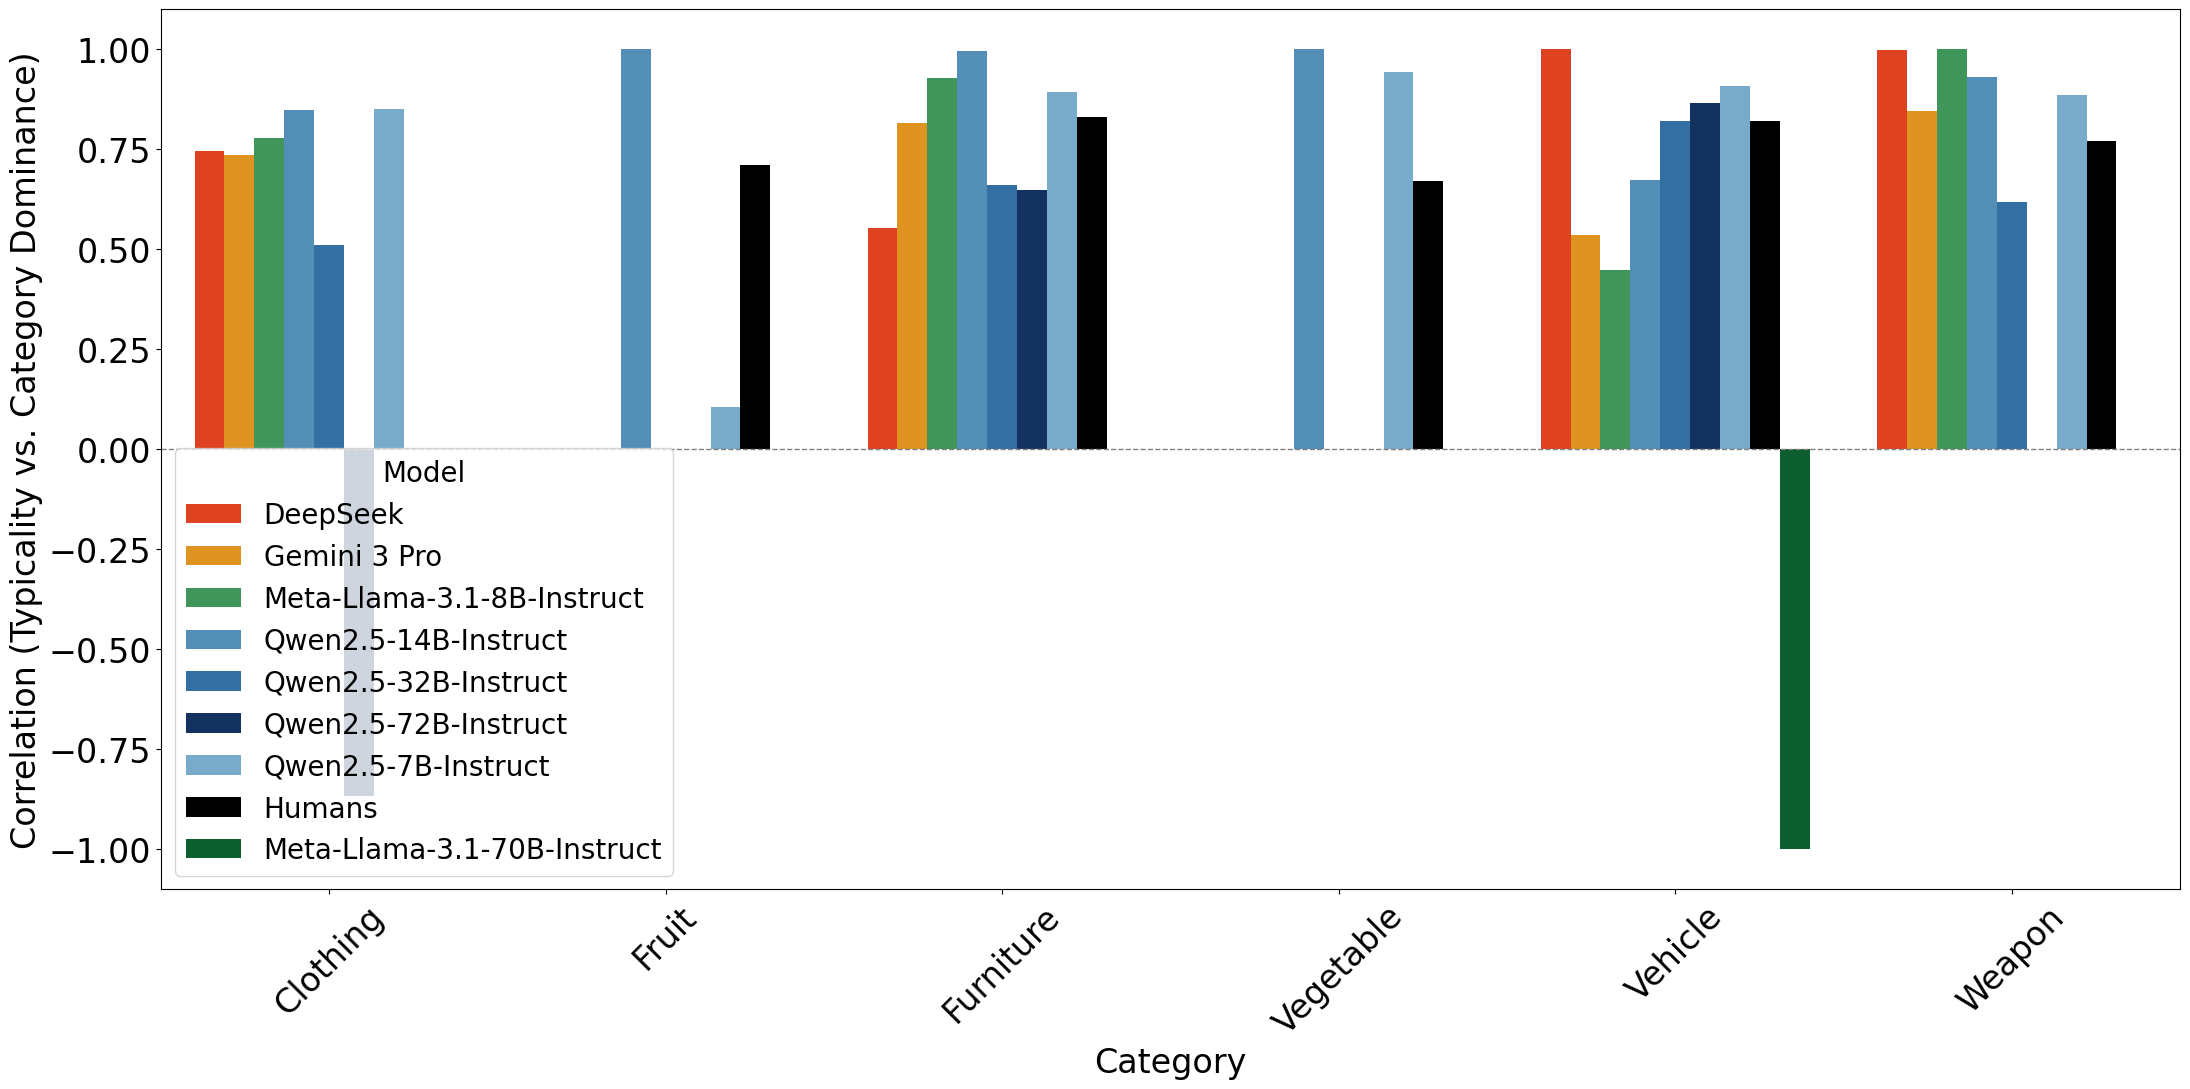

In [ ]:
correlation_results = []

grouped = results_df.groupby(['Model', 'Category'])

for (model, category), group in grouped:
    if len(group) > 1:  
        corr, pval = spearmanr(group['category_dominance_deco'], group['Category Frequency'])
        correlation_results.append({
            'Model': model,
            'Category': category,
            'Correlation': corr,
            'p_value': pval
        })

correlation_df = pd.DataFrame(correlation_results)

categories_to_remove = ["Toy", "Bird", "Carpenter's tool", "Sport"]
correlation_df = correlation_df[~correlation_df['Category'].isin(categories_to_remove)]

correlation_df['Model'] = correlation_df['Model'].replace({
    'gemini-3-pro': 'Gemini 3 Pro',
    'deepseek-chat': 'DeepSeek'
})

humans_data = {
    'Model': ['Humans'] * 5,
    'Category': ['Fruit', 'Furniture', 'Vegetable', 'Vehicle', 'Weapon'],
    'Correlation': [0.71, 0.83, 0.67, 0.82, 0.77],
    'p_value': [0.0]*5 
}
humans_df = pd.DataFrame(humans_data)

combined_df = pd.concat([humans_df, correlation_df], ignore_index=True)

combined_df['Model_order'] = combined_df['Model'].apply(lambda x: 0 if x=='Humans' else 1)
combined_df = combined_df.sort_values(by=['Category', 'Model_order', 'Model']).drop(columns='Model_order')

print("Spearman correlations for all model-category pairs:")
for _, row in combined_df.iterrows():
    sig = ''
    if row['p_value'] < 0.001:
        sig = '***'
    elif row['p_value'] < 0.01:
        sig = '**'
    elif row['p_value'] < 0.05:
        sig = '*'
    print(f"Category: {row['Category']}, Model: {row['Model']}, p-value: {row['p_value']:.4f} {sig}")

plt.figure(figsize=(22, 11))
model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'Humans': 'black'
}
sns.barplot(data=combined_df, x='Category', y='Correlation', hue='Model', palette=model_palette)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Correlation (Typicality vs. Category Dominance)', fontsize=24)
plt.xlabel('Category', fontsize=24)
plt.legend(title='Model', loc='lower left', fontsize=20, title_fontsize=20)
plt.xticks(rotation=45, fontsize=24)
plt.yticks(rotation=0, fontsize=24)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.savefig('03_PropertiesFigures/figure_catdominance_catfreq_correlations.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
correlation_results = []

grouped = results_df.groupby(['Model', 'Category'])

for (model, category), group in grouped:
    
    valid_group = group[['category_dominance_deco', 'Category Frequency']].dropna()
    n_items = len(valid_group)

    if n_items > 1:  
        corr, pval = spearmanr(
            valid_group['category_dominance_deco'],
            valid_group['Category Frequency']
        )
        correlation_results.append({
            'Model': model,
            'Category': category,
            'N': n_items,
            'Correlation': corr,
            'p_value': pval
        })

correlation_df = pd.DataFrame(correlation_results)

categories_to_remove = ["Toy", "Bird", "Carpenter's tool", "Sport"]
correlation_df = correlation_df[~correlation_df['Category'].isin(categories_to_remove)]

correlation_df['Model'] = correlation_df['Model'].replace({
    'gemini-3-pro': 'Gemini 3 Pro',
    'deepseek-chat': 'DeepSeek'
})

humans_data = {
    'Model': ['Humans'] * 5,
    'Category': ['Fruit', 'Furniture', 'Vegetable', 'Vehicle', 'Weapon'],
    'N': [20, 20, 20, 20, 20],  
    'Correlation': [0.71, 0.83, 0.67, 0.82, 0.77],
    'p_value': [0.0] * 5
}
humans_df = pd.DataFrame(humans_data)

combined_df = pd.concat([humans_df, correlation_df], ignore_index=True)

combined_df['Model_order'] = combined_df['Model'].apply(lambda x: 0 if x == 'Humans' else 1)
combined_df = combined_df.sort_values(by=['Category', 'Model_order', 'Model']).drop(columns='Model_order')

print("Spearman correlations for all model-category pairs:")
for _, row in combined_df.iterrows():
    sig = ''
    if pd.notna(row['p_value']):
        if row['p_value'] < 0.001:
            sig = '***'
        elif row['p_value'] < 0.01:
            sig = '**'
        elif row['p_value'] < 0.05:
            sig = '*'

    pval_str = f"{row['p_value']:.4f}" if pd.notna(row['p_value']) else "NaN"

    print(
        f"Category: {row['Category']}, "
        f"Model: {row['Model']}, "
        f"N: {int(row['N'])}, "
        f"Correlation: {row['Correlation']:.4f}, "
        f"p-value: {pval_str} {sig}"
    )

print("\nFull correlation table:")
print(combined_df[['Category', 'Model', 'N', 'Correlation', 'p_value']].to_string(index=False))

plt.figure(figsize=(22, 11))
model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'Humans': 'black'
}
sns.barplot(data=combined_df, x='Category', y='Correlation', hue='Model', palette=model_palette)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Correlation (Typicality vs. Category Dominance)', fontsize=24)
plt.xlabel('Category', fontsize=24)
plt.legend(title='Model', loc='lower left', fontsize=20, title_fontsize=20)
plt.xticks(rotation=45, fontsize=24)
plt.yticks(rotation=0, fontsize=24)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.savefig('03_PropertiesFigures/figure_catdominance_catfreq_correlations.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
correlation_results = []

grouped = results_df.groupby(['Model', 'Category'])

for (model, category), group in grouped:
    n_total = len(group)

    valid_group = group[['category_dominance_deco', 'Category Frequency']].dropna()
    n_used = len(valid_group)

    if n_used > 1:
        corr, pval = spearmanr(
            valid_group['category_dominance_deco'],
            valid_group['Category Frequency']
        )
        correlation_results.append({
            'Model': model,
            'Category': category,
            'N_total': n_total,   
            'N_used': n_used,     
            'Correlation': corr,
            'p_value': pval
        })

correlation_df = pd.DataFrame(correlation_results)
print(correlation_df[['Category', 'Model', 'N_total', 'N_used', 'Correlation', 'p_value']].to_string(index=False))

        Category                       Model  N_total  N_used  Correlation      p_value
             Toy Meta-Llama-3.1-70B-Instruct        3       3    -0.866025 3.333333e-01
         Vehicle Meta-Llama-3.1-70B-Instruct        2       2    -1.000000          NaN
Carpenter's tool  Meta-Llama-3.1-8B-Instruct        3       3     0.500000 6.666667e-01
        Clothing  Meta-Llama-3.1-8B-Instruct        7       7     0.776899 3.987739e-02
       Furniture  Meta-Llama-3.1-8B-Instruct        9       9     0.928232 3.038040e-04
             Toy  Meta-Llama-3.1-8B-Instruct       11      11     0.934122 2.571932e-05
         Vehicle  Meta-Llama-3.1-8B-Instruct        6       6     0.447214 3.739010e-01
          Weapon  Meta-Llama-3.1-8B-Instruct        5       5     1.000000 1.404265e-24
            Bird        Qwen2.5-14B-Instruct        2       2     1.000000          NaN
Carpenter's tool        Qwen2.5-14B-Instruct        3       3     0.500000 6.666667e-01
        Clothing        Qwen2.5-

C:\Users\AS\AppData\Local\Temp\ipykernel_13524\1366394538.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(


In [ ]:
correlation_results = []

grouped = results_df.groupby(['Model', 'Category'])

for (model, category), group in grouped:
    
    correlation, _ = spearmanr(group['category_dominance_deco'], group['Category Frequency'])
    correlation_results.append({'Model': model, 'Category': category, 'Correlation': correlation})

correlation_df = pd.DataFrame(correlation_results)

categories_to_remove = ["Toy", "Bird", "Carpenter's tool", "Sport"]
correlation_df = correlation_df[~correlation_df['Category'].isin(categories_to_remove)]

correlation_df['Model'] = correlation_df['Model'].replace({
    'gemini-3-pro': 'Gemini 3 Pro',
    'deepseek-chat': 'DeepSeek'
})

model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'Humans': 'black'  
}

humans_data = {
    'Model': ['Humans'] * 5,
    'Category': ['Fruit', 'Furniture', 'Vegetable', 'Vehicle', 'Weapon'],
    'Correlation': [0.71, 0.83, 0.67, 0.82, 0.77]
}

humans_df = pd.DataFrame(humans_data)

combined_df = pd.concat([humans_df, correlation_df], ignore_index=True)

combined_df = combined_df.sort_values(by=['Category', 'Model'], key=lambda x: x.map({'Humans': 0}).fillna(1))

plt.figure(figsize=(22, 11))
sns.barplot(data=combined_df, x='Category', y='Correlation', hue='Model', palette=model_palette)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Correlation (Typicality vs. Category Dominance)', fontsize=24)
plt.xlabel('Category', fontsize=24)
plt.legend(title='Model', loc='lower left', fontsize=20, title_fontsize = 20)
plt.xticks(rotation=45, fontsize=24)
plt.yticks(rotation=0, fontsize=24)
plt.ylim(-1.1,1.1)
plt.tight_layout()
plt.savefig('03_PropertiesFigures/figure_catdominance_catfreq_correlations.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [16]:
qwen_14_results_df = results_df[results_df['Model'] == 'Qwen2.5-14B-Instruct']
qwen_14_results_df

,Item,Model,Category,Category Frequency,category_dominance_deco
52,apron,Qwen2.5-14B-Instruct,Clothing,21,3
53,apron,Qwen2.5-14B-Instruct,Carpenter's tool,3,2
54,apron,Qwen2.5-14B-Instruct,Toy,2,1
55,apron,Qwen2.5-14B-Instruct,Furniture,2,1
56,backpack,Qwen2.5-14B-Instruct,Clothing,15,3
...,...,...,...,...,...
124,wallet,Qwen2.5-14B-Instruct,Furniture,2,1
125,wheelchair,Qwen2.5-14B-Instruct,Vehicle,24,3
126,wheelchair,Qwen2.5-14B-Instruct,Furniture,4,2
127,wheelchair,Qwen2.5-14B-Instruct,Clothing,3,1
